## Import Library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import statistics as st

from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler as ss, OneHotEncoder as ohe, PolynomialFeatures as pf
from sklearn.linear_model import LinearRegression as lr
from sklearn.compose import ColumnTransformer as ct
from sklearn.datasets import make_regression as mr 
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score as r2, mean_absolute_error as mae, mean_squared_error as mse 
from sklearn.metrics import accuracy_score as AS, precision_score as ps , recall_score as rs, f1_score as f1, confusion_matrix as cm, classification_report as cr

import plotly.graph_objects as go
import plotly.express as px

# Load Dataset

In [2]:
dat = pd.read_csv(r"E:\DATA FOR TEST\50 Startups\50_Startups.csv")
df = dat.copy()

# Exploratry Data Analysis 

In [3]:
print("Information\n", df.info())
print("\nDescribe\n", df.describe())
print("\nEmpty Values\n", df.isnull().sum())
df['Profit'] = df['Profit'].fillna(df['Profit'].mean())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           44 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB
Information
 None

Describe
            R&D Spend  Administration  Marketing Spend         Profit
count      50.000000       50.000000        50.000000      44.000000
mean    73721.615600   121344.639600    211025.097800  112466.881364
std     45902.256482    28017.802755    122290.310726   43000.569645
min         0.000000    51283.140000         0.000000   14681.400000
25%     39936.370000   103730.875000    129300.132500   81173.235000
50%     73051.080000   122699.795000    212716.240000  104145.345000
75%    10160

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


# X Variable and Y Variable(Target Variable)

In [4]:
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
print(len(x))
print(len(y))

50
50


# Train Test Split

In [5]:
x_train, x_test, y_train, y_test = tts(x, y, test_size = 0.2, random_state = 42)

# No Reshaping x Data (only for Single Feature Linear Regression) Feature Encoding

In [6]:
# Feature Encoding
Encoder = ct(transformers = [('encoder', ohe(), [3])], remainder = 'passthrough')
x_train = np.array(Encoder.fit_transform(x_train)) 
x_test = np.array(Encoder.transform(x_test))
print(x_train)
print(x_test)

[[0.0 1.0 0.0 93863.75 127320.38 249839.44]
 [0.0 1.0 0.0 142107.34 91391.77 366168.42]
 [1.0 0.0 0.0 44069.95 51283.14 197029.42]
 [0.0 0.0 1.0 120542.52 148718.95 311613.29]
 [0.0 0.0 1.0 144372.41 118671.85 383199.62]
 [1.0 0.0 0.0 134615.46 147198.87 127716.82]
 [0.0 1.0 0.0 27892.92 84710.77 164470.71]
 [0.0 1.0 0.0 1315.46 115816.21 297114.46]
 [1.0 0.0 0.0 0.0 135426.92 0.0]
 [0.0 0.0 1.0 114523.61 122616.84 261776.23]
 [1.0 0.0 0.0 123334.88 108679.17 304981.62]
 [1.0 0.0 0.0 78013.11 121597.55 264346.06]
 [0.0 0.0 1.0 77044.01 99281.34 140574.81]
 [1.0 0.0 0.0 46426.07 157693.92 210797.67]
 [0.0 0.0 1.0 61136.38 152701.92 88218.23]
 [0.0 0.0 1.0 165349.2 136897.8 471784.1]
 [1.0 0.0 0.0 22177.74 154806.14 28334.72]
 [0.0 0.0 1.0 72107.6 127864.55 353183.81]
 [0.0 1.0 0.0 55493.95 103057.49 214634.81]
 [0.0 0.0 1.0 131876.9 99814.71 362861.36]
 [0.0 0.0 1.0 65605.48 153032.06 107138.38]
 [1.0 0.0 0.0 100671.96 91790.61 249744.55]
 [0.0 1.0 0.0 28663.76 127056.21 201126.82]
 [1.

# Feature Scaling

In [7]:
Scaler = ss()
x_train = Scaler.fit_transform(x_train)
x_test = Scaler.transform(x_test)

# Linear Regresssion

In [8]:
# Modal initilization
linear_model = lr()

# Modal Learning From Train Data SET
linear_model.fit(x_train, y_train)

# Modal Predicting X Test Data
y_pred = linear_model.predict(x_test)


# Visulation of Prediction and Test

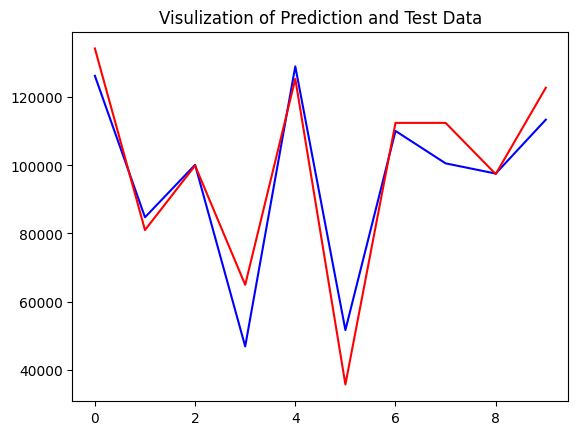

In [9]:
plt.plot(y_pred, color = 'Blue', label = "Prediction")
plt.plot(y_test, color = 'Red', label = "Test")
plt.title("Visulization of Prediction and Test Data")
plt.show()


# Result Matrix 

In [10]:
print(" -   - "*10)
print("Low Is Better\n")
print("Mean Absolute Error : \t", round(mae(y_test, y_pred), 2))
print("Mean Squared Error : \t", round(mse(y_test, y_pred), 2))
print("Root Mean Squared Error : ", round(np.sqrt(mae(y_test, y_pred)), 2))
print(" -   - "*10)
print("High Is Better\n")

r2_Score = round(r2(y_test, y_pred),3)
print("R2 Score : \t", r2_Score)

n = x_test.shape[0]
k = x_test.shape[1]
Adj_R2 = 1 - (((1 - r2_Score) * (n-1))/(n-1-k))
print("Adjusted R2 Score : ", round((Adj_R2), 2))

 -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   - 
Low Is Better

Mean Absolute Error : 	 7350.58
Mean Squared Error : 	 90885016.55
Root Mean Squared Error :  85.74
 -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   - 
High Is Better

R2 Score : 	 0.891
Adjusted R2 Score :  0.67


# Test the Random Data on Model

In [11]:
# Initilize Data
Rand_data = [[-0.77459667, -0.69388867,  1.52752523, -1.3373705 , -2.0935051 ,
        -0.23469468]]
# Feature Scaling
Rand_data = Scaler.transform(Rand_data)
# Predict Value
val_pred = linear_model.predict(Rand_data)
# Show Result
val_pred

array([54784.59455509])

# Creating Artificial Data By Make Regression

In [12]:
# Assign Data
x, y = mr(n_samples = 100, n_informative = 2, n_features = 2, noise = 50, n_targets = 1)

# Featch and Convert Data
df = pd.DataFrame({'Feature1' : x[:, 0], 'Feature2' : x[:, 1], 'target' : 'y'})

# Shape
print("Shape", df.shape)

# Sample 
df.head()

Shape (100, 3)


,Feature1,Feature2,target
0,-1.087772,1.002458,y
1,-0.658702,1.011357,y
2,-0.476945,0.383534,y
3,-1.348588,1.720443,y
4,0.067049,0.200833,y


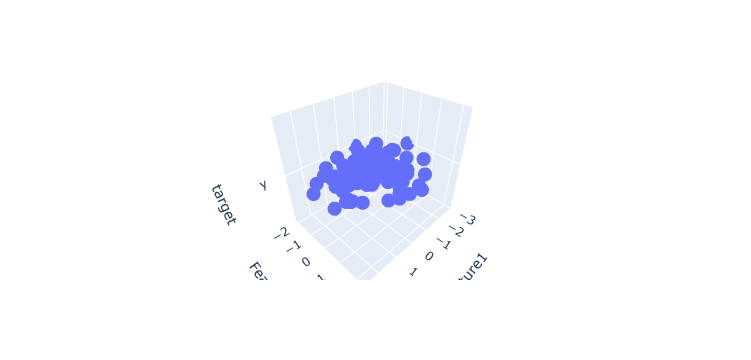

In [13]:
# Plot Plotly library
fig = px.scatter_3d(df, x='Feature1', y='Feature2', z = 'target')
fig.show()

In [14]:
# Split Data in Training and testing
x_train, x_test, y_train, y_test = tts(x, y, test_size = 0.2, random_state = 42)

In [15]:
# Model Learning from Training data
linear_model = lr()
linear_model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
# Model Prediction by Model
y_pred = linear_model.predict(x_test)

In [17]:
# Result
print(" -   - "*10)
print("Low Is Better\n")
print("Mean Absolute Error : \t", round(mae(y_test, y_pred), 2))
print("Mean Squared Error : \t", round(mse(y_test, y_pred), 2))
print("Root Mean Squared Error : ", round(np.sqrt(mae(y_test, y_pred)), 2))
print(" -   - "*10)
print("High Is Better\n")

r2_Score = round(r2(y_test, y_pred),3)
print("R2 Score : \t", r2_Score)

n = x_test.shape[0]
k = x_test.shape[0]
Adj_R2 = 1 - (((1 - r2_Score) * (n-1))/(n-1-k))
print("Adjusted R2 Score : ", round((Adj_R2), 2))

 -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   - 
Low Is Better

Mean Absolute Error : 	 44.84
Mean Squared Error : 	 2907.87
Root Mean Squared Error :  6.7
 -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   -  -   - 
High Is Better

R2 Score : 	 0.554
Adjusted R2 Score :  9.47


# Polynominal Regression

In [18]:
x = 6 * np.random.rand(200, 1)-3
y = 0.8 *x**2 + 0.9*x + 2 + np.random.rand(200, 1)

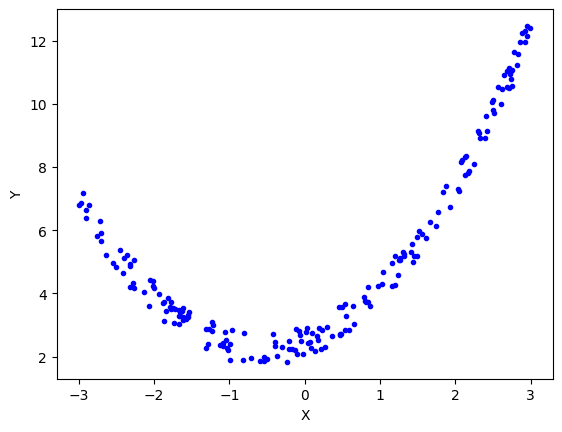

In [19]:
# Visulizing the Data Distribution
plt.plot(x,y,'.b')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [20]:
# Training and Testing Split
x_train, x_test, y_train, y_test = tts(x, y, test_size = 0.2, random_state = 3)

# Model Initilizing(Linear Regression) (Feature Encoding and Scaling not required for artificial data)
lr_model = lr()

# Model Learning by Training Data
lr_model.fit(x_train, y_train)

# Model Prediction by Testing Data
y_pred_linear = lr_model.predict(x_test)

R2 Score : 	 0.43539857606390064


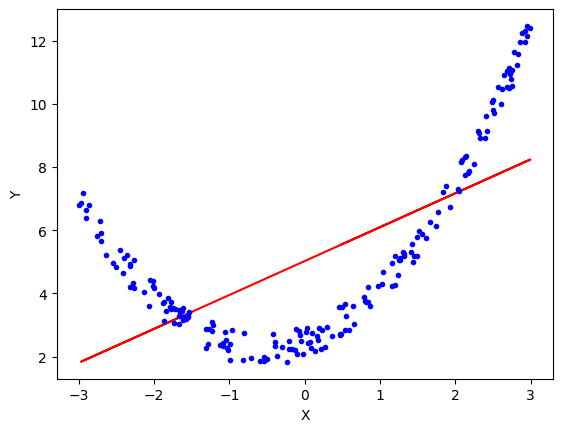

In [21]:
# Result
r2_score_lr = r2(y_test, y_pred_linear)
print("R2 Score : \t", r2_score_lr)

# Visulization
plt.plot(x_train, lr_model.predict(x_train), color = 'r')
plt.plot(x, y, 'b.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# # Visulization
# plt.plot(y_pred_linear, color='blue', label='Prediction')     # line
# plt.plot(y_test, 'b.', label='Test')                           # blue dots

# plt.title("Visualization of Prediction and Test Data")
# plt.legend()
# plt.show()

R2 Score : 	 0.43539857606390064


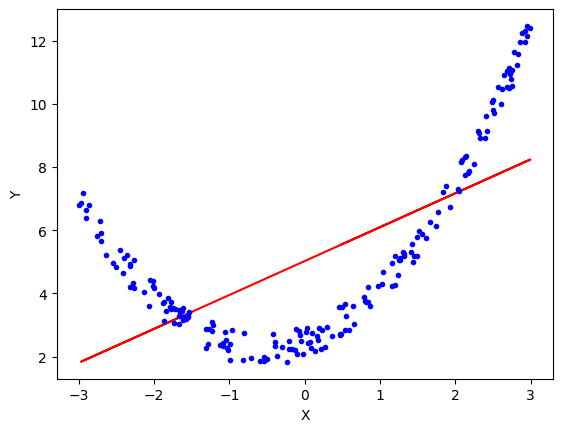

In [31]:
# Result
r2_score_lr = r2(y_test, y_pred_linear)
print("R2 Score : \t", r2_score_lr)

# Visulization
plt.plot(x_train, lr_model.predict(x_train), color = 'r')
plt.plot(x, y, 'b.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# # Visulization
# plt.plot(y_pred_linear, color='blue', label='Prediction')     # line
# plt.plot(y_test, 'b.', label='Test')                           # blue dots

# plt.title("Visualization of Prediction and Test Data")
# plt.legend()
# plt.show()

R2 Score 0.9849786679677973


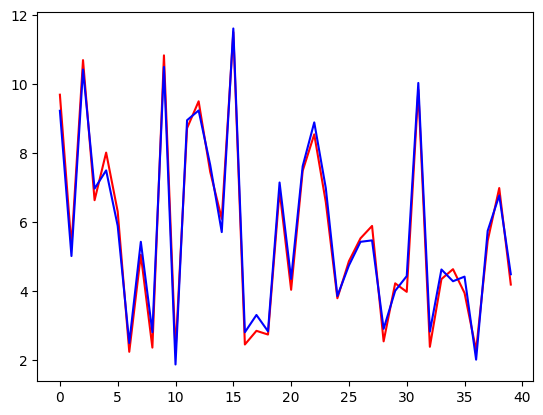

In [22]:
# Polynomial Features Assigning with Degree = 2
poly = pf(degree = 2, include_bias = True)

# Convert Training Data To Polynomial With Degree 2
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

# Linear Model
lr_model = lr()
lr_model.fit(x_train_poly, y_train)
y_pred = lr_model.predict(x_test_poly)

# Result R2
print("R2 Score", r2(y_pred, y_test))

# Visulize now
plt.plot(y_pred, color = "Red", label = "Prediction")
plt.plot(y_test, color = "Blue", label = "Testing")
plt.show()

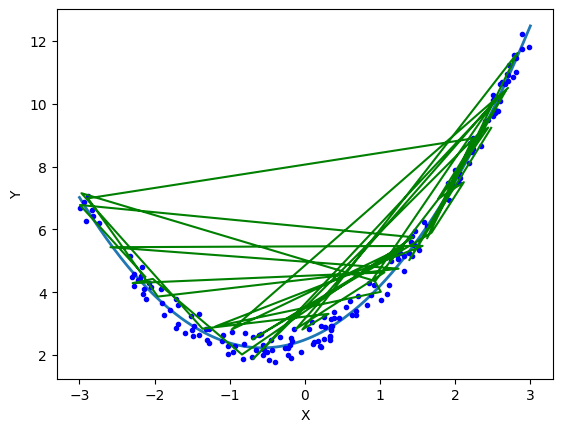

In [23]:
# Testing on New Data
x_new = np.linspace(-3, 3, 200).reshape(200, 1)
x_new_poly = poly.transform(x_new)
y_new = lr_model.predict(x_new_poly)

# Visulization
plt.plot(x_new,y_new, label = "Prediction", linewidth = 2)
plt.plot(x_train, y_train, 'b.', label = "Training")
plt.plot(x_test, y_test, "g", label = "Test")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

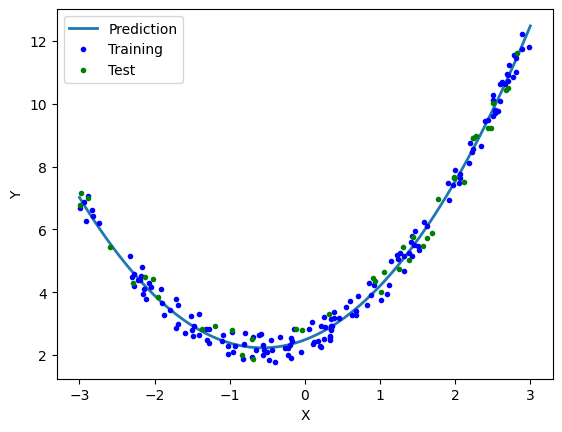

In [24]:
# Visualization
plt.plot(x_new, y_new, label="Prediction", linewidth=2)
plt.plot(x_train, y_train, 'b.', label="Training")
plt.plot(x_test, y_test, 'g.', label="Test")

plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()



In [25]:
# Polynomial Features Assigning with Degree = 2
poly = pf(degree = 2, include_bias = True)

# Convert Training Data To Polynomial With Degree 2
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

# Linear Model
lr_model = lr()
lr_model.fit(x_train_poly, y_train)
y_pred = lr_model.predict(x_test_poly)

# Result R2
print("R2 Score", r2(y_pred, y_test))

# # Visulize now
# plt.figure(figsize = (6,6))
# plt.plot(y_pred, color = "Red", label = "Prediction")
# plt.plot(y_test, color = "Blue", label = "Testing")
# plt.show()

R2 Score 0.9849786679677973


In [26]:
def  diff_deg(deg):

    # Polynomial Features Assigning with Degree = 2
    poly = pf(degree = deg, include_bias = True)

    # Convert Training Data To Polynomial With Degree 2
    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.transform(x_test)
    
    # Linear Model
    lr_model = lr()
    lr_model.fit(x_train_poly, y_train)
    y_pred = lr_model.predict(x_test_poly)
    
    # Result R2
    print("R2 Score", r2(y_pred, y_test))
    
    # Visulize now
    plt.figure(figsize = (6,6))
    plt.plot(y_pred, color = "Red", label = "Prediction")
    plt.plot(y_test, color = "Blue", label = "Testing")
    plt.show()

    # Visualization
    plt.plot(x_new, y_new, label="Prediction", linewidth=2)
    plt.plot(x_train, y_train, 'b.', label="Training")
    plt.plot(x_test, y_test, 'g.', label="Test")
    
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()




R2 Score 0.9850248219398618


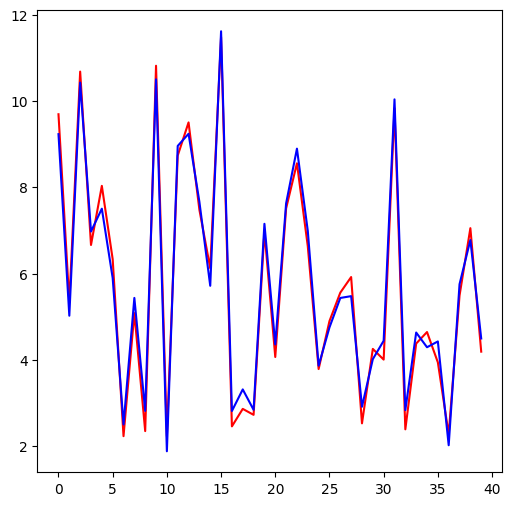

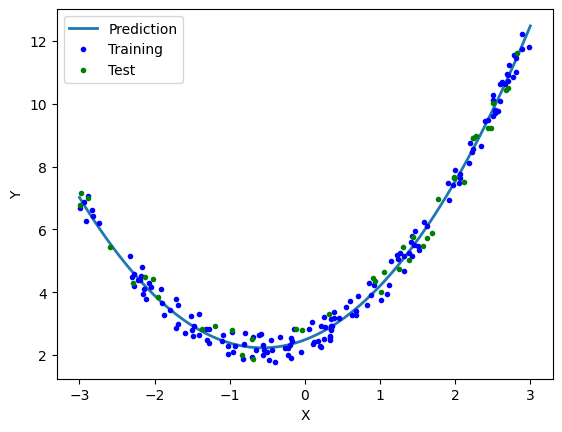

In [27]:
diff_deg(3)

R2 Score 0.9850248219398618


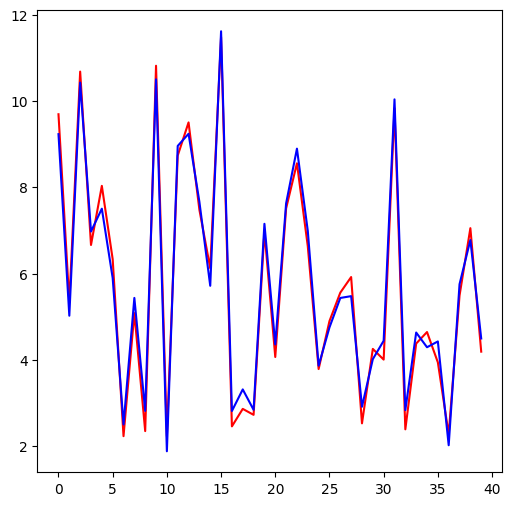

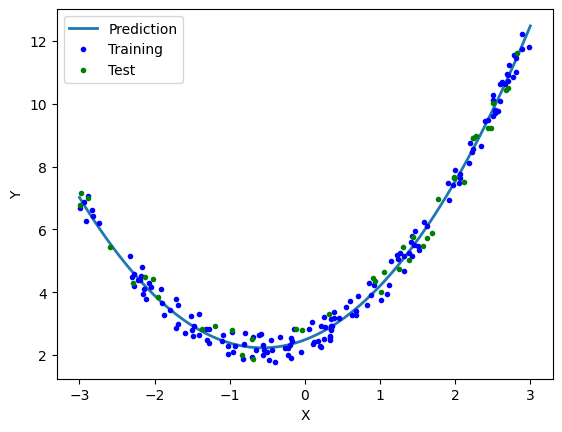

In [28]:
diff_deg(3)

R2 Score 0.9532924509368194


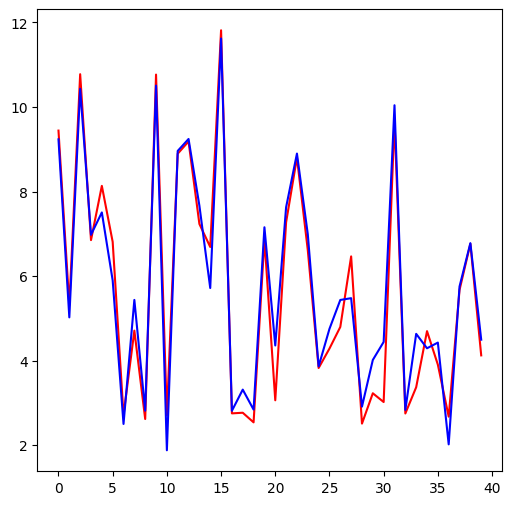

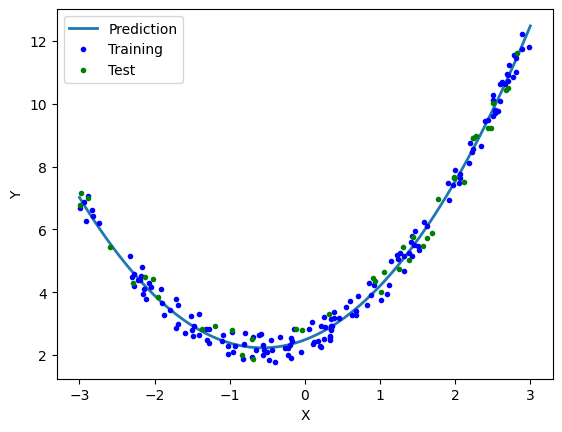

In [29]:
diff_deg(30)

R2 Score -0.04057271048714339


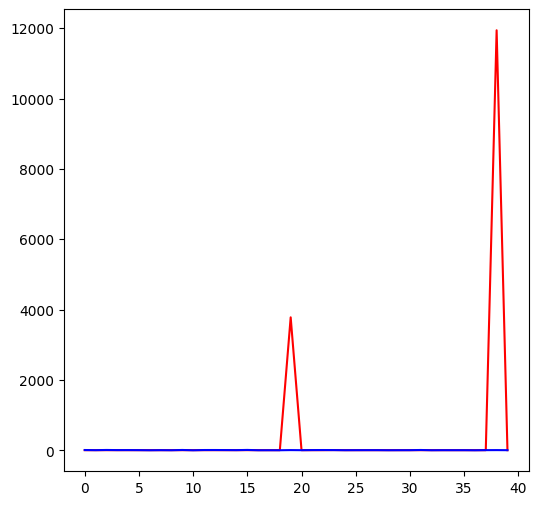

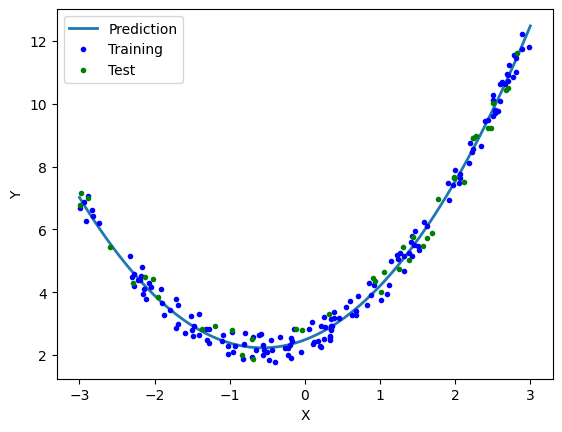

In [30]:
diff_deg(300)

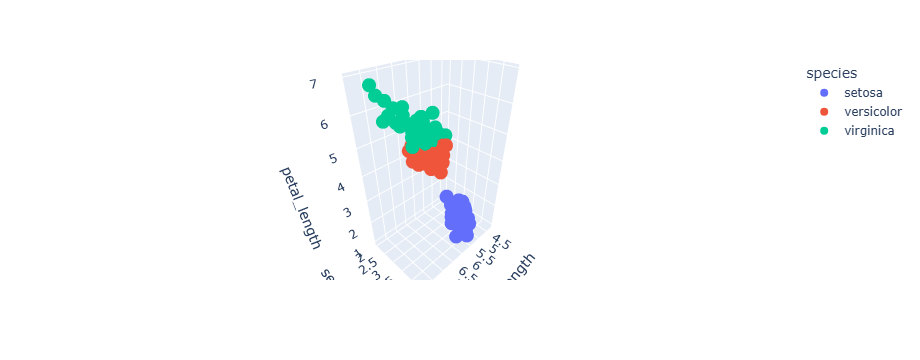

In [31]:
# Load dataset
df = px.data.iris()

# 3D scatter plot
fig = px.scatter_3d(
    df,
    x="sepal_length",
    y="sepal_width",
    z="petal_length",
    color="species"
)

fig.show()
